In [35]:
import sys, os

project_root = '/Users/andrepfrommer/Desktop/neural_data_science_project'
sys.path.append(project_root)

poisson_gpfa_path = os.path.join(project_root, 'utils', 'poisson-gpfa')  # adjust as needed
sys.path.append(poisson_gpfa_path)

from utils.utils import *
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

In [36]:
data = load_saved_data("data_with_spikes_and_speed")

In [37]:
class GPFADataset:
    """Create a GPFA-compatible dataset restricted to trials matching one
    stimulus condition (a single value of `parameter`).

    Each stimulus presentation matching `parameter == parameter_value` is
    treated as one trial. `self.data[trial]["Y"]` has shape (ydim, T), raw
    spike counts (no transform, no mean subtraction) — suitable for a
    Poisson-GPFA fit.
    """

    def __init__(
        self,
        data=None,
        session_id="B",
        stimulus="natural_scenes",
        parameter="orientation",
        parameter_value=0,
        duration_min=0.25,
    ):
        session = data["sessions"][session_id]
        spikes = np.asarray(session["spikes"], dtype=float)
        t = np.asarray(session["t"], dtype=float)
        stim_table = session["stim_tables"][stimulus].copy()
        running_speed = np.asarray(session["running_speed_filtered"][0], dtype=float)

        # Restrict to the requested condition before doing anything else.
        stim_table = stim_table[stim_table[parameter] == parameter_value].reset_index(drop=True)
        print(parameter, parameter_value, len(stim_table), "presentations")
        
        dt_sec = float(np.median(np.diff(t)))
        dt_ms = dt_sec * 1000.0

        # Filter presentations shorter than duration_min.
        durations = stim_table["end"] - stim_table["start"]
        min_samples = int(round(duration_min / dt_sec))
        stim_table = stim_table[durations >= min_samples].reset_index(drop=True)
        
        
        if stim_table.empty:
            raise ValueError(
                f"No presentations survive duration filtering for {parameter}={parameter_value!r}."
            )

        # Fixed trial length: shortest presentation, kept even.
        T = int((stim_table["end"] - stim_table["start"]).min())
        T -= T % 2
        if T < 1:
            raise ValueError(f"Computed trial length is too short for {parameter}={parameter_value!r}.")

        max_start = min(spikes.shape[1], running_speed.shape[0]) - T
        stim_metadata_cols = [c for c in stim_table.columns if c not in ("start", "end")]

        trials = []
        for _, row in stim_table.iterrows():
            start_idx = int(row["start"])
            if start_idx > max_start:
                continue  # not enough samples left in the recording for this trial
            stop_idx = start_idx + T

            Y = spikes[:, start_idx:stop_idx]

            # get spike times 
            spike_time = []
            for trace in Y:
                nz = np.flatnonzero(np.isfinite(trace) & (trace > 0))
                if nz.size == 0:
                    spike_time.append(np.array([], dtype=float))
                    continue
                counts = np.maximum(1, np.rint(trace[nz]).astype(int))
                spike_time.append(np.repeat(nz, counts) * dt_sec)

            trial_dict = {
                "Y": Y,
                "spike_time": spike_time,
                "start_idx": start_idx,
                "end_idx": stop_idx,
                "running_speed": running_speed[start_idx:stop_idx],
            }
            trial_dict.update({col: row[col] for col in stim_metadata_cols})
            trials.append(trial_dict)


        self.data = trials
        self.trial_durs = [T * dt_sec for _ in trials]
        self.trialDur = T * dt_ms
        self.binSize = dt_ms
        self.numTrials = len(trials)
        self.ydim = spikes.shape[0]
        self.T = T
        self.session_id = session_id
        self.stimulus = stimulus
        self.parameter = parameter
        self.parameter_value = parameter_value

In [38]:
data_drifting_gratings_0 = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    parameter_value=0,
    duration_min=1.0,
)

train_set_0, test_set_0 = util.splitTrainingTestDataset(
    data_drifting_gratings_0, numTrainingTrials=data_drifting_gratings_0.numTrials - 10, numTestTrials=10
)

data_drifting_gratings_45 = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    parameter_value=45,
    duration_min=1.0,
)

train_set_45, test_set_45 = util.splitTrainingTestDataset(
    data_drifting_gratings_45, numTrainingTrials=data_drifting_gratings_45.numTrials - 10, numTestTrials=10
)

data_drifting_gratings_90 = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    parameter_value=90,
    duration_min=1.0,
)

train_set_90, test_set_90 = util.splitTrainingTestDataset(
    data_drifting_gratings_90, numTrainingTrials=data_drifting_gratings_90.numTrials - 10, numTestTrials=10
)

data_drifting_gratings_135 = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    parameter_value=135,
    duration_min=1.0,
)

train_set_135, test_set_135 = util.splitTrainingTestDataset(
    data_drifting_gratings_135, numTrainingTrials=data_drifting_gratings_135.numTrials - 10, numTestTrials=10
)

data_drifting_gratings_180 = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    parameter_value=180,
    duration_min=1.0,
)

train_set_180, test_set_180 = util.splitTrainingTestDataset(
    data_drifting_gratings_180, numTrainingTrials=data_drifting_gratings_180.numTrials - 10, numTestTrials=10
)

orientation 0 75 presentations
orientation 45 75 presentations
orientation 90 75 presentations
orientation 135 74 presentations
orientation 180 75 presentations


In [8]:
print(data_drifting_gratings_0.numTrials) # nr of different frames presented
print(data_drifting_gratings_0.ydim) # nr of neurons
print(data_drifting_gratings_0.T) # nr of time bins per trial
print(data_drifting_gratings_0.trialDur) # rounded trial duration in milliseconds
print(data_drifting_gratings_0.binSize) # bin size in milliseconds
print(data_drifting_gratings_0.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_drifting_gratings_0.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_drifting_gratings_0.data[0]['running_speed']) # running speed for the first trial

75
47
58
1925.78125
33.203125
(47, 58)
(2,)
[10.67378839 10.93061755 10.70809749 10.27609847  9.85226867  9.4189789
  8.8319943   8.08736369  7.37356327  6.86363749  6.57613799  6.44585261
  6.41149305  6.33884181  5.95501552  5.09982616  4.03449498  3.24900126
  2.9416493   2.88283245  2.79210848  2.65028904  2.57684919  2.60590126
  2.76770385  3.22987028  4.08358508  5.05582013  5.67667911  5.73714947
  5.48387201  5.38423776  5.73423232  6.51561254  7.58112583  8.79938912
 10.03117148 11.19383084 12.33166361 13.41011544 14.11759824 14.11820491
 13.44834158 12.48026638 11.60092161 11.06272902 10.952805   11.10926286
 11.17726006 10.90873201 10.41219471 10.03692055  9.96881174  9.99812536
  9.73192659  8.94154369  7.68925056  6.29238599]


### Fit the GPFA models

In [39]:
# hyperparameter
NR_TEST_TRIALS = 10
XDIM = 5
NR_EM_ITER = 20
BATCH_SIZE = 5

In [40]:
xval_drifting_gratings_0 = util.crossValidation(
    experiment = data_drifting_gratings_0,
    numTrainingTrials = data_drifting_gratings_0.numTrials - NR_TEST_TRIALS,
    numTestTrials = NR_TEST_TRIALS,
    maxXdim = XDIM,
    maxEMiter = NR_EM_ITER, 
    batchSize = BATCH_SIZE,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:   3 of  20, nPLL: = -20.2694

KeyboardInterrupt: 

In [11]:
xval_drifting_gratings_45 = util.crossValidation(
    experiment = data_drifting_gratings_45,
    numTrainingTrials = data_drifting_gratings_45.numTrials - 10,
    numTestTrials = NR_TEST_TRIALS,
    maxXdim = XDIM,
    maxEMiter = NR_EM_ITER, 
    batchSize = BATCH_SIZE,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method


+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -20.7396Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -20.3647Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


...

/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    4 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -20.2931Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    5 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -20.2236Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [12]:
xval_drifting_gratings_90 = util.crossValidation(
    experiment = data_drifting_gratings_90,
    numTrainingTrials = data_drifting_gratings_90.numTrials - NR_TEST_TRIALS,
    numTestTrials = NR_TEST_TRIALS,
    maxXdim = XDIM,
    maxEMiter = NR_EM_ITER,
    batchSize = BATCH_SIZE,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method


+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -29.1821Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -29.1065Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


...

/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    4 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -28.6015Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    5 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -28.6206Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [13]:
xval_drifting_gratings_135 = util.crossValidation(
    experiment = data_drifting_gratings_135,
    numTrainingTrials = data_drifting_gratings_135.numTrials - NR_TEST_TRIALS,
    numTestTrials = NR_TEST_TRIALS,
    maxXdim = XDIM,
    maxEMiter = NR_EM_ITER,
    batchSize = BATCH_SIZE,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method


+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -15.4090Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -15.2858Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


...

/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    4 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -15.3091Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    5 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -15.2715Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [14]:
xval_drifting_gratings_180 = util.crossValidation(
    experiment = data_drifting_gratings_180,
    numTrainingTrials = data_drifting_gratings_180.numTrials - NR_TEST_TRIALS,
    numTestTrials = NR_TEST_TRIALS,
    maxXdim = XDIM,
    maxEMiter = NR_EM_ITER,
    batchSize = BATCH_SIZE,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -18.5415Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -18.5114Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    3 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -18.4481Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    4 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -18.4226Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    5 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   20 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  20 of  20, nPLL: = -18.4195Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


## Test error for different latent dimensions 

In [15]:
def baseline_error(xval, dataset) -> float:
    baseline_error = 0.0
    
    # pick the first model
    fit = xval[0]
    ydim, xdim = np.shape(fit.optimParams["C"])
    for tr in range(dataset.numTrials):
        # loop over neurons (y dimension)
        for nrn in range(dataset.ydim):
            # predict y with X the identity matrix
            x_id = np.ones((xdim, dataset.T))
            y_pred = np.exp(
                fit.optimParams["C"][nrn].dot(x_id).T + fit.optimParams["d"][nrn]
            )
            #compute SSE
            baseline_error += np.dot(
                dataset.data[tr]["Y"][nrn] - y_pred, 
                dataset.data[tr]["Y"][nrn] - y_pred
            )
    
    return baseline_error

In [16]:
# Orientation 0

errs_0 = []
# loop over five optimized models (latent dimensionalty) and predict error
for fit in xval_drifting_gratings_0.fits:
    predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set_0)
    errs_0.append(predErr)

Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...


In [17]:
baseline_error_0 = baseline_error(xval_drifting_gratings_0.fits, test_set_0)

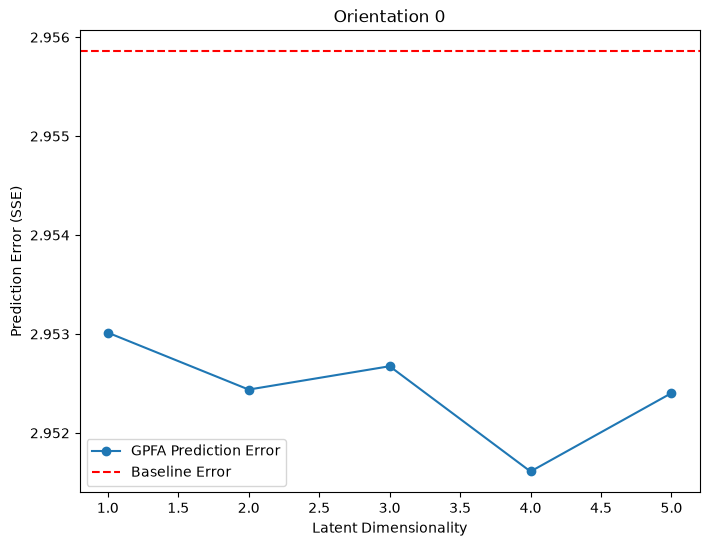

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, len(errs_0) + 1), errs_0, marker='o', label='GPFA Prediction Error')
ax.axhline(y=baseline_error_0, color='r', linestyle='--', label='Baseline Error')
ax.set_xlabel('Latent Dimensionality')
ax.set_ylabel('Prediction Error (SSE)')
ax.set_title("Orientation 0")
ax.legend()


In [19]:
# orientation 45
errs_45 = []
# loop over five optimized models (latent dimensionalty) and predict error
for fit in xval_drifting_gratings_45.fits:
    predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set_45)
    errs_45.append(predErr)

baseline_error_45 = baseline_error(xval_drifting_gratings_45.fits, test_set_45)

Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...


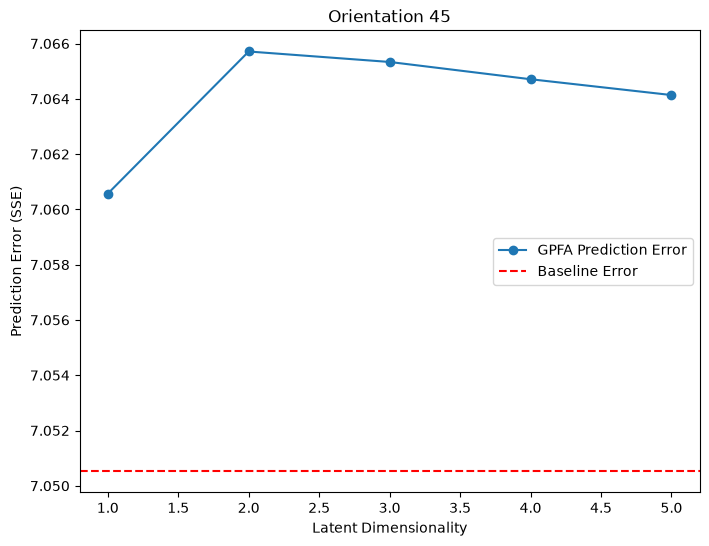

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, len(errs_45) + 1), errs_45, marker='o', label='GPFA Prediction Error')
ax.axhline(y=baseline_error_45, color='r', linestyle='--', label='Baseline Error')
ax.set_xlabel('Latent Dimensionality')
ax.set_ylabel('Prediction Error (SSE)')
ax.set_title("Orientation 45")
ax.legend()

In [21]:
#orientation 90
errs_90 = []
# loop over five optimized models (latent dimensionalty) and predict error
for fit in xval_drifting_gratings_90.fits:
    predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set_90)
    errs_90.append(predErr)

baseline_error_90 = baseline_error(xval_drifting_gratings_90.fits, test_set_90)

Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...


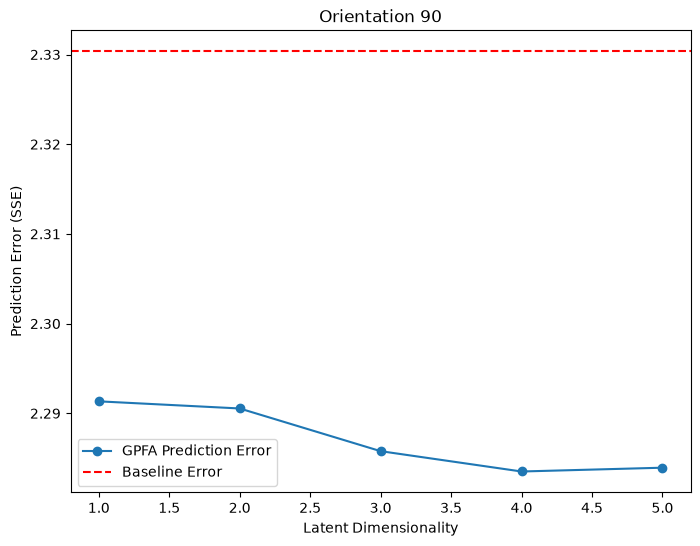

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, len(errs_90) + 1), errs_90, marker='o', label='GPFA Prediction Error')
ax.axhline(y=baseline_error_90, color='r', linestyle='--', label='Baseline Error')
ax.set_xlabel('Latent Dimensionality')
ax.set_ylabel('Prediction Error (SSE)')
ax.set_title("Orientation 90")
ax.legend()

In [23]:
# orientation 180 
errs_180 = []
for fit in xval_drifting_gratings_180.fits:
    predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set_180)
    errs_180.append(predErr)

baseline_error_180 = baseline_error(xval_drifting_gratings_180.fits, test_set_180)

Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...


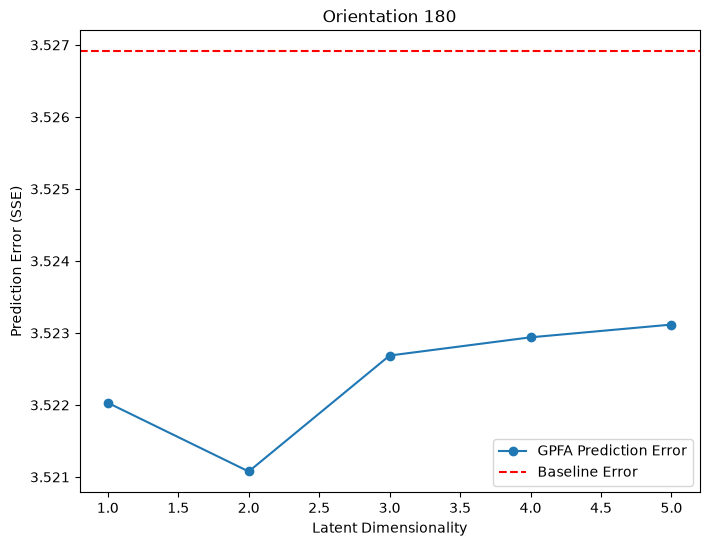

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, len(errs_180) + 1), errs_180, marker='o', label='GPFA Prediction Error')
ax.axhline(y=baseline_error_180, color='r', linestyle='--', label='Baseline Error')
ax.set_xlabel('Latent Dimensionality')
ax.set_ylabel('Prediction Error (SSE)')
ax.set_title("Orientation 180")
ax.legend()
        

TODO: Is this the right way to compute the baseline error?

## Noise correlations and their analytical approximations using GPFA parameters

In [25]:
# compute raw covariance for each orientation condition
trial_sums_0 = np.array([np.sum(trial['Y'], axis=1) for trial in data_drifting_gratings_0.data])
raw_cov_0 = np.cov(trial_sums_0, rowvar=False)

trial_sums_45 = np.array([np.sum(trial['Y'], axis=1) for trial in data_drifting_gratings_45.data])
raw_cov_45 = np.cov(trial_sums_45, rowvar=False)

trial_sums_90 = np.array([np.sum(trial['Y'], axis=1) for trial in data_drifting_gratings_90.data])
raw_cov_90 = np.cov(trial_sums_90, rowvar=False)

trial_sums_135 = np.array([np.sum(trial['Y'], axis=1) for trial in data_drifting_gratings_135.data])
raw_cov_135 = np.cov(trial_sums_135, rowvar=False)

trial_sums_180 = np.array([np.sum(trial['Y'], axis=1) for trial in data_drifting_gratings_180.data])
raw_cov_180 = np.cov(trial_sums_180, rowvar=False)

In [26]:
# compute covariance approximation using GPFA for each orientation condition

approx_cov_0 = []
for fit in xval_drifting_gratings_0.fits:
    approx_cov, _ = cov_anal(fit)
    approx_cov_0.append(approx_cov)

approx_cov_45 = []
for fit in xval_drifting_gratings_45.fits:
    approx_cov, _ = cov_anal(fit)
    approx_cov_45.append(approx_cov)

approx_cov_90 = []
for fit in xval_drifting_gratings_90.fits:
    approx_cov, _ = cov_anal(fit)
    approx_cov_90.append(approx_cov)

approx_cov_135 = []
for fit in xval_drifting_gratings_135.fits:
    approx_cov, _ = cov_anal(fit)
    approx_cov_135.append(approx_cov)
    
approx_cov_180 = []
for fit in xval_drifting_gratings_180.fits:
    approx_cov, _ = cov_anal(fit)
    approx_cov_180.append(approx_cov)

In [27]:
def plot_covariances(raw_cov, approx_cov, orientation):
    n_dims = len(approx_cov)
    fig, axes = plt.subplots(1, n_dims + 1, figsize=((n_dims + 1) * 5, 5))

    im0 = axes[0].imshow(raw_cov, cmap="bwr")
    axes[0].set_title("Raw Covariance")
    axes[0].set_xlabel("neuron")
    axes[0].set_ylabel("neuron")

    for i, cov in enumerate(approx_cov):
        im = axes[i + 1].imshow(cov, cmap="bwr")
        axes[i + 1].set_title(f"GPFA approx; (dim={i + 1})")
        axes[i + 1].set_xlabel("neuron")
        axes[i + 1].set_ylabel("neuron")

    fig.suptitle(f"Orientation {orientation}°", fontsize=16)
    fig.tight_layout()
    return fig, axes

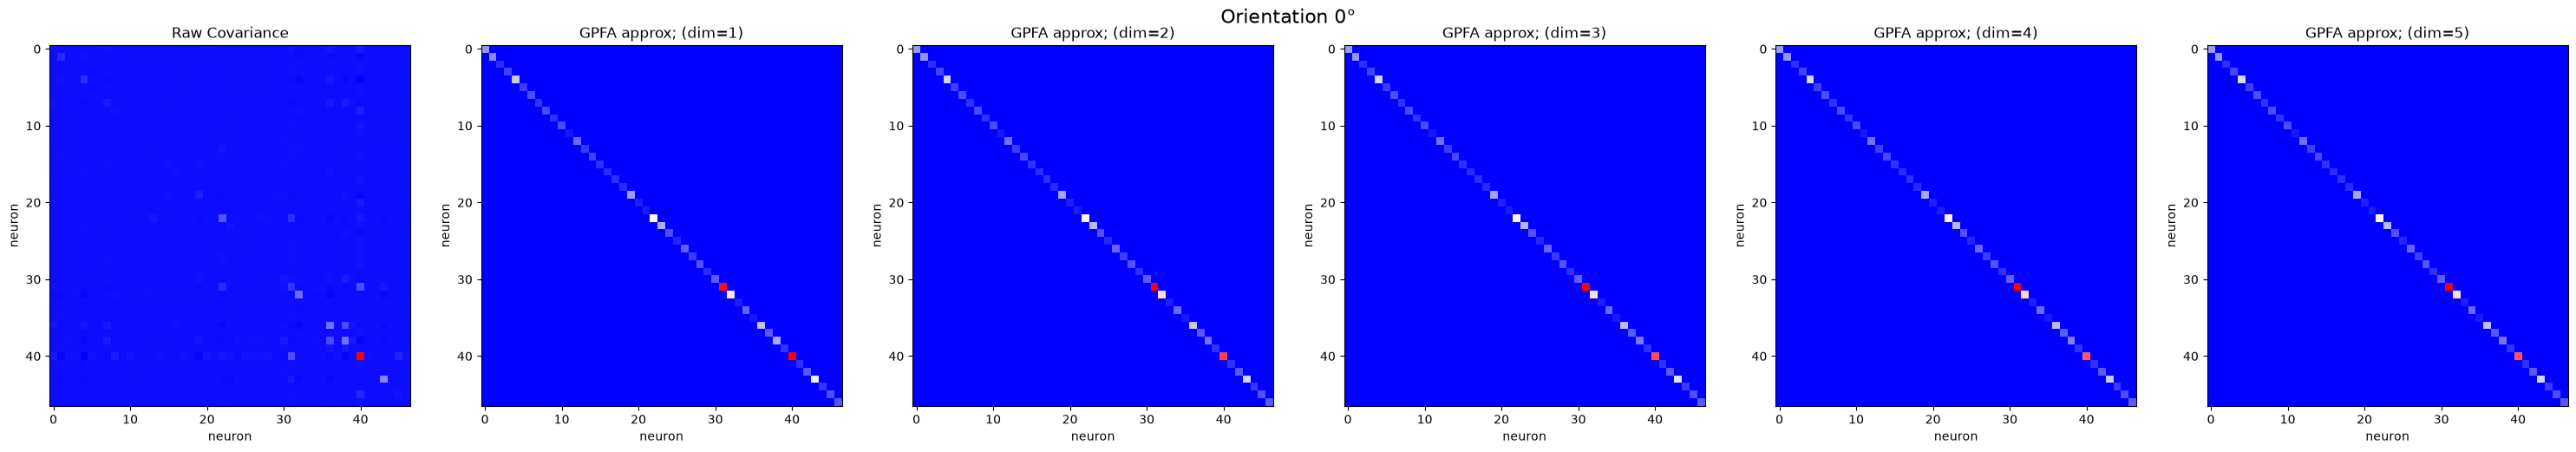

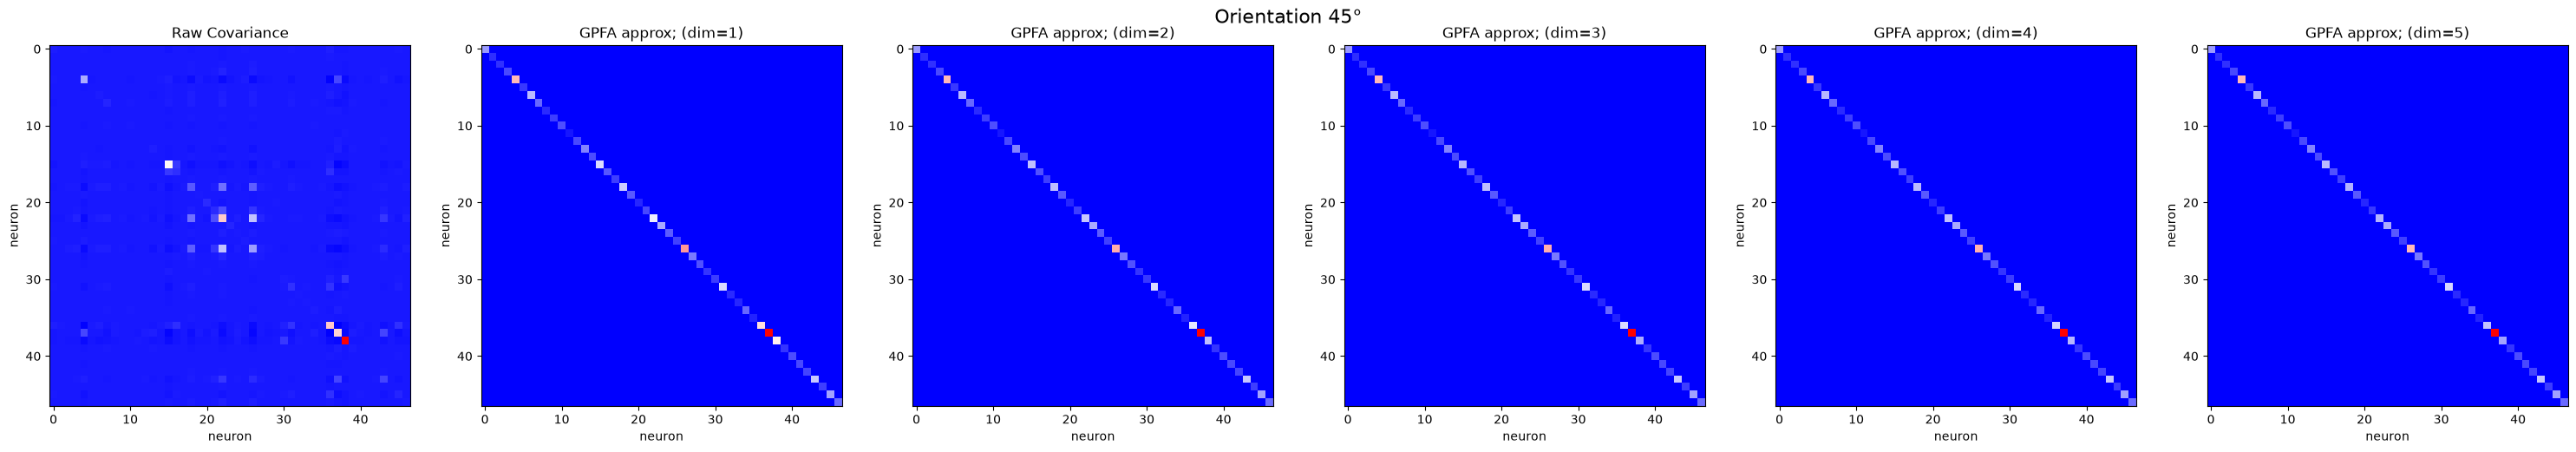

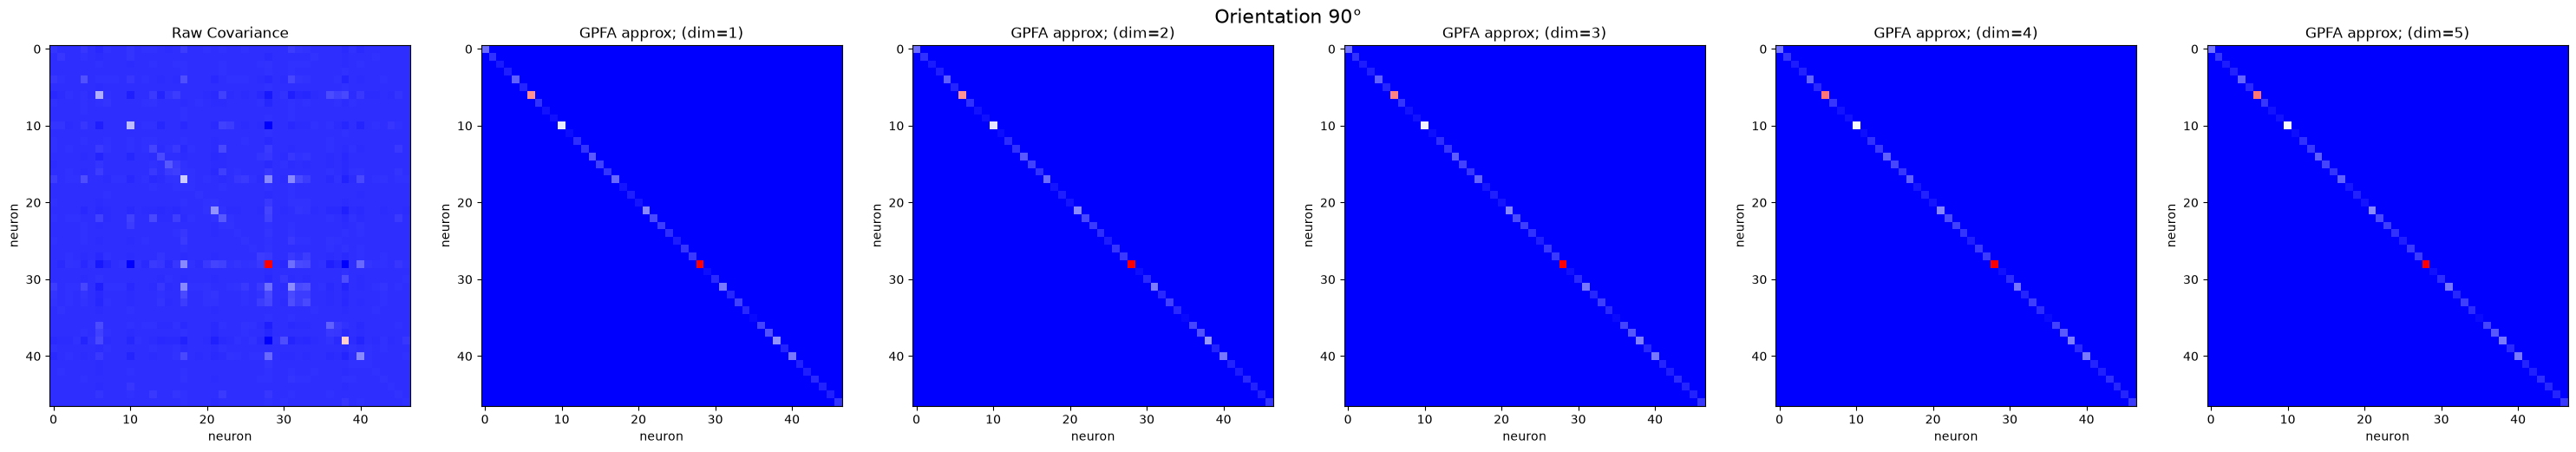

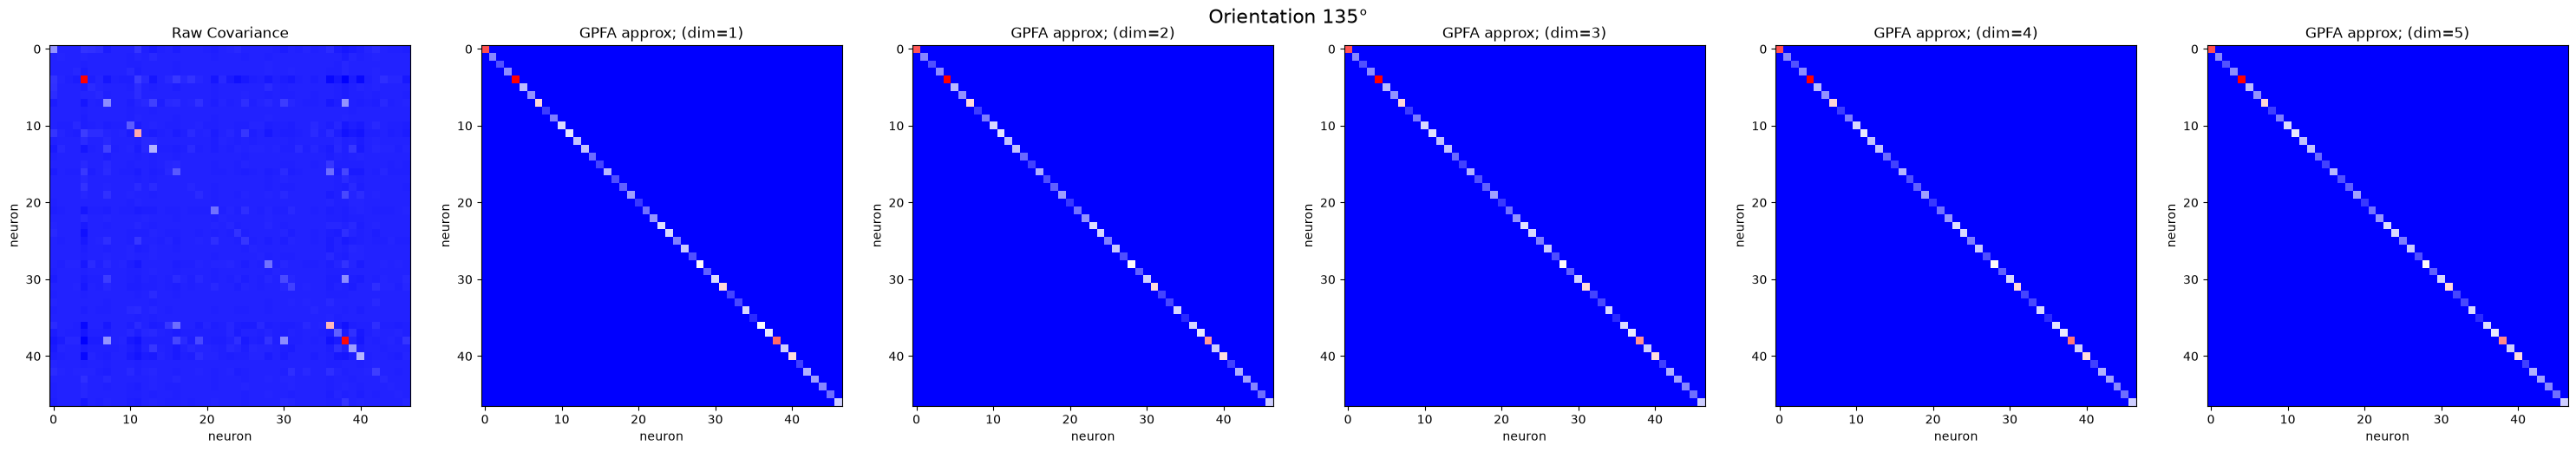

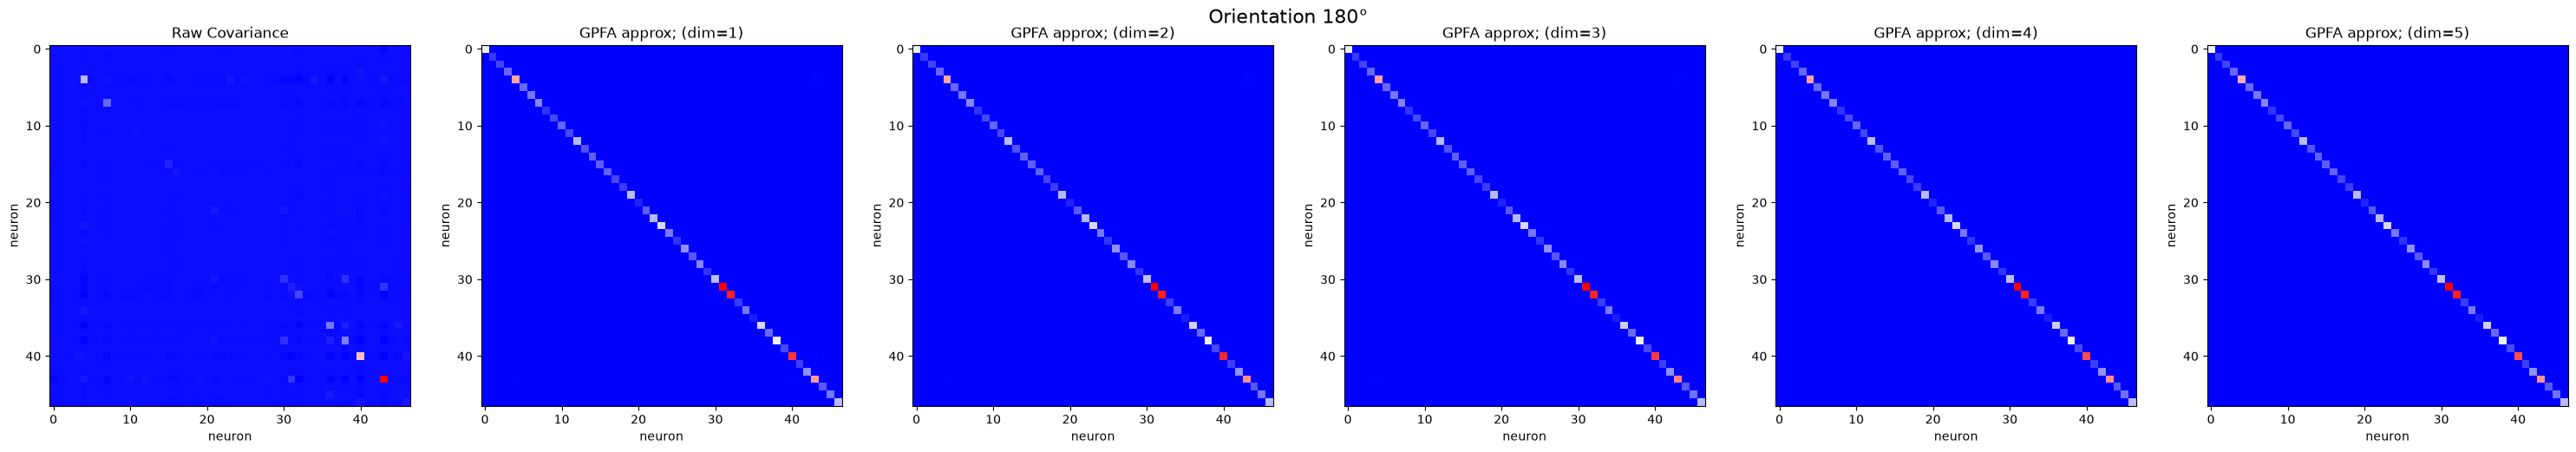

In [28]:
fig, axes = plot_covariances(raw_cov_0, approx_cov_0, orientation=0)
fig, axes = plot_covariances(raw_cov_45, approx_cov_45, orientation=45)
fig, axes = plot_covariances(raw_cov_90, approx_cov_90, orientation=90)
fig, axes = plot_covariances(raw_cov_135, approx_cov_135, orientation=135)
fig, axes = plot_covariances(raw_cov_180, approx_cov_180, orientation=180)

## Compare latent trace with running speed

In [29]:
def plot_gpfa_latent_and_speed(
    xval, 
    data, 
    nr_trials=5
    ):
    """
    For each of the first `nr_trials` trials, plot spike-time eventplots in
    the first column, and running speed (left axis) overlaid with the
    inferred latent state (right axis) in one column per fitted model.
    """
    fits = xval.fits
    n_cols = 1 + len(fits)

    fig, axes = plt.subplots(nr_trials, n_cols, figsize=(5 * n_cols, 3 * nr_trials), squeeze=False)

    time = np.arange(data.T) * (data.binSize / 1000.0)  # seconds

    for row in range(nr_trials):
        trial = data.data[row]

        # Column 0: spike raster
        ax_raster = axes[row, 0]
        ax_raster.eventplot(trial["spike_time"], colors="black")
        ax_raster.set_title(f"Trial {row + 1} Spike Times")
        ax_raster.set_xlabel("Time (s)")
        ax_raster.set_ylabel("Neuron Index")

        # One column per fit (e.g. per candidate latent dimensionality)
        for col, fit in enumerate(fits, start=1):
            ax_speed = axes[row, col]

            # Match this trial to the fit's own trial list via start_idx,
            # since fit.experiment.data may not share data.data's order.
            start_to_postmean = {
                t["start_idx"]: i for i, t in enumerate(fit.experiment.data)
            }
            post_mean_idx = start_to_postmean.get(trial["start_idx"])

            # Speed on the left axis
            ax_speed.plot(time, trial["running_speed"], color="blue", label="Running Speed")
            ax_speed.tick_params(axis="y", labelcolor="blue")
            ax_speed.set_ylabel("Running speed", color="blue")

            # Latent state on the right axis
            ax_latent = ax_speed.twinx()
            latent = fit.infRes["post_mean"][post_mean_idx]  # (latent_dim, T)
            for dim in range(latent.shape[0]):
                ax_latent.plot(time, latent[dim], color="orange", alpha=0.8, label=f"Latent dim {dim}")
            ax_latent.tick_params(axis="y", labelcolor="orange")
            ax_latent.set_ylabel("Latent state", color="orange")

            xdim = fit.optimParams.get("C", np.zeros((0, 0))).shape[1] if hasattr(fit, "optimParams") else col
            if row == 0:
                ax_speed.set_title(f"xdim={xdim}", fontsize=10)

            if row == nr_trials - 1:
                ax_speed.set_xlabel("Time (s)", fontsize=10)

    fig.suptitle(f"Orientation {data.parameter_value}°", fontsize=25)
    
    # one legend for all subplots
    lines_speed, labels_speed = ax_speed.get_legend_handles_labels()
    lines_latent, labels_latent = ax_latent.get_legend_handles_labels()
    fig.legend(lines_speed + lines_latent, labels_speed + labels_latent, fontsize=7, loc='upper right')
    
    fig.tight_layout()
    
    return fig, axes

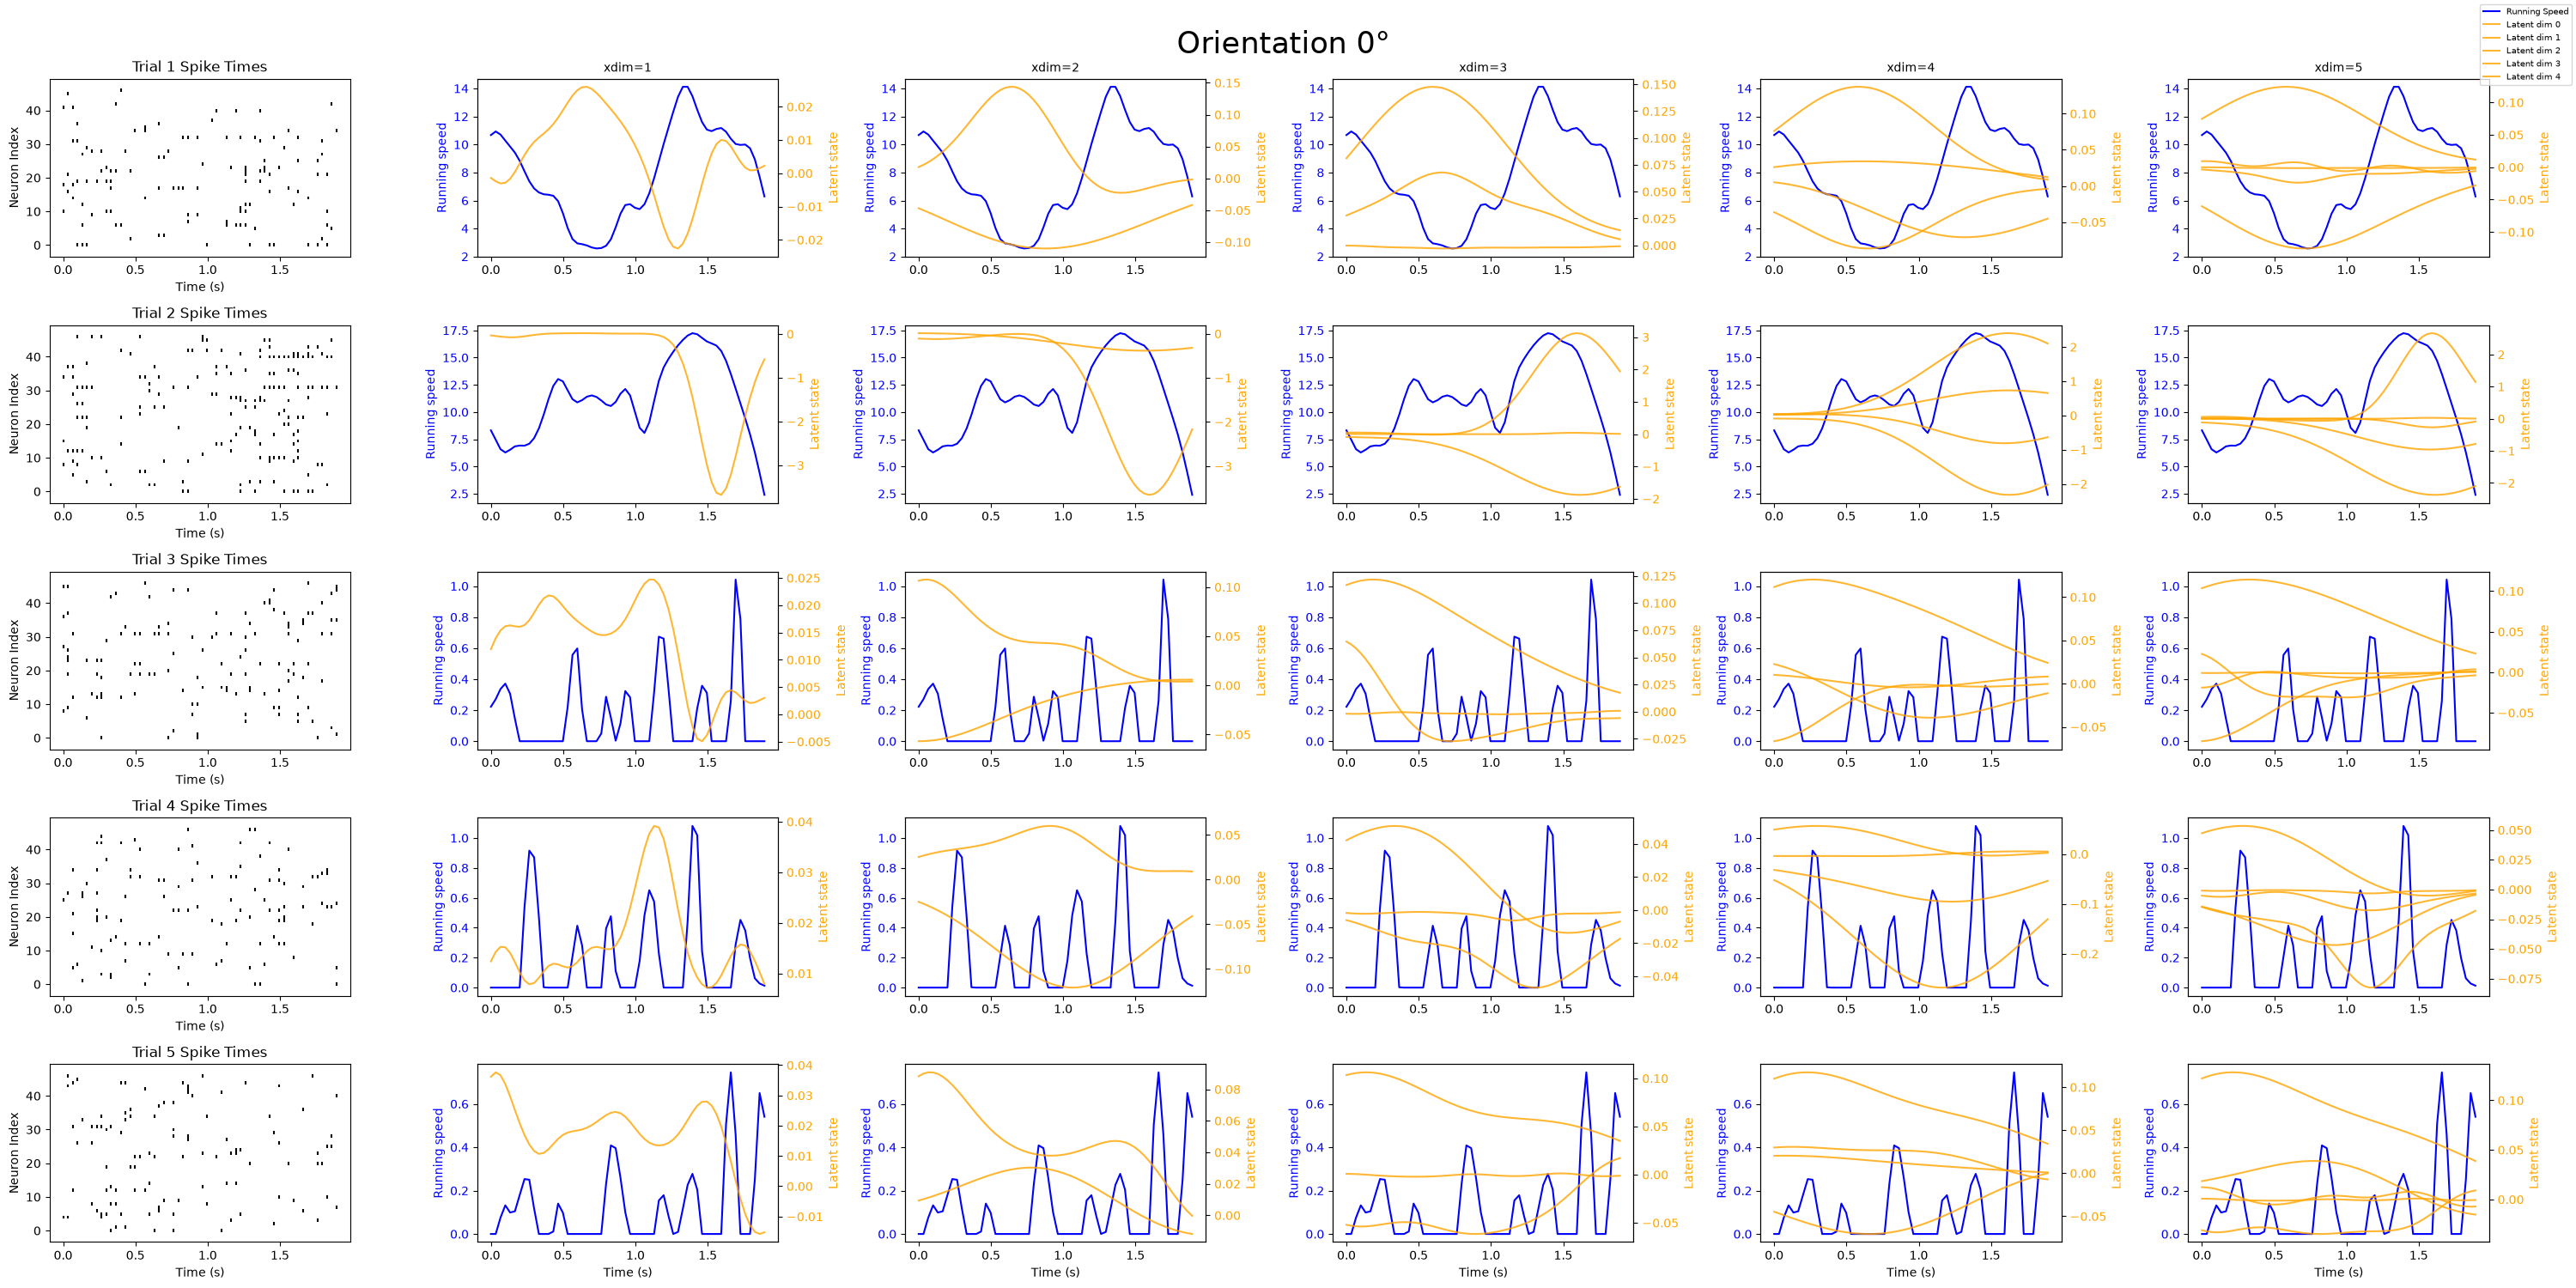

In [30]:
fig, axes = plot_gpfa_latent_and_speed(
    xval=xval_drifting_gratings_0,
    data=data_drifting_gratings_0,
    nr_trials=5
)
plt.show()

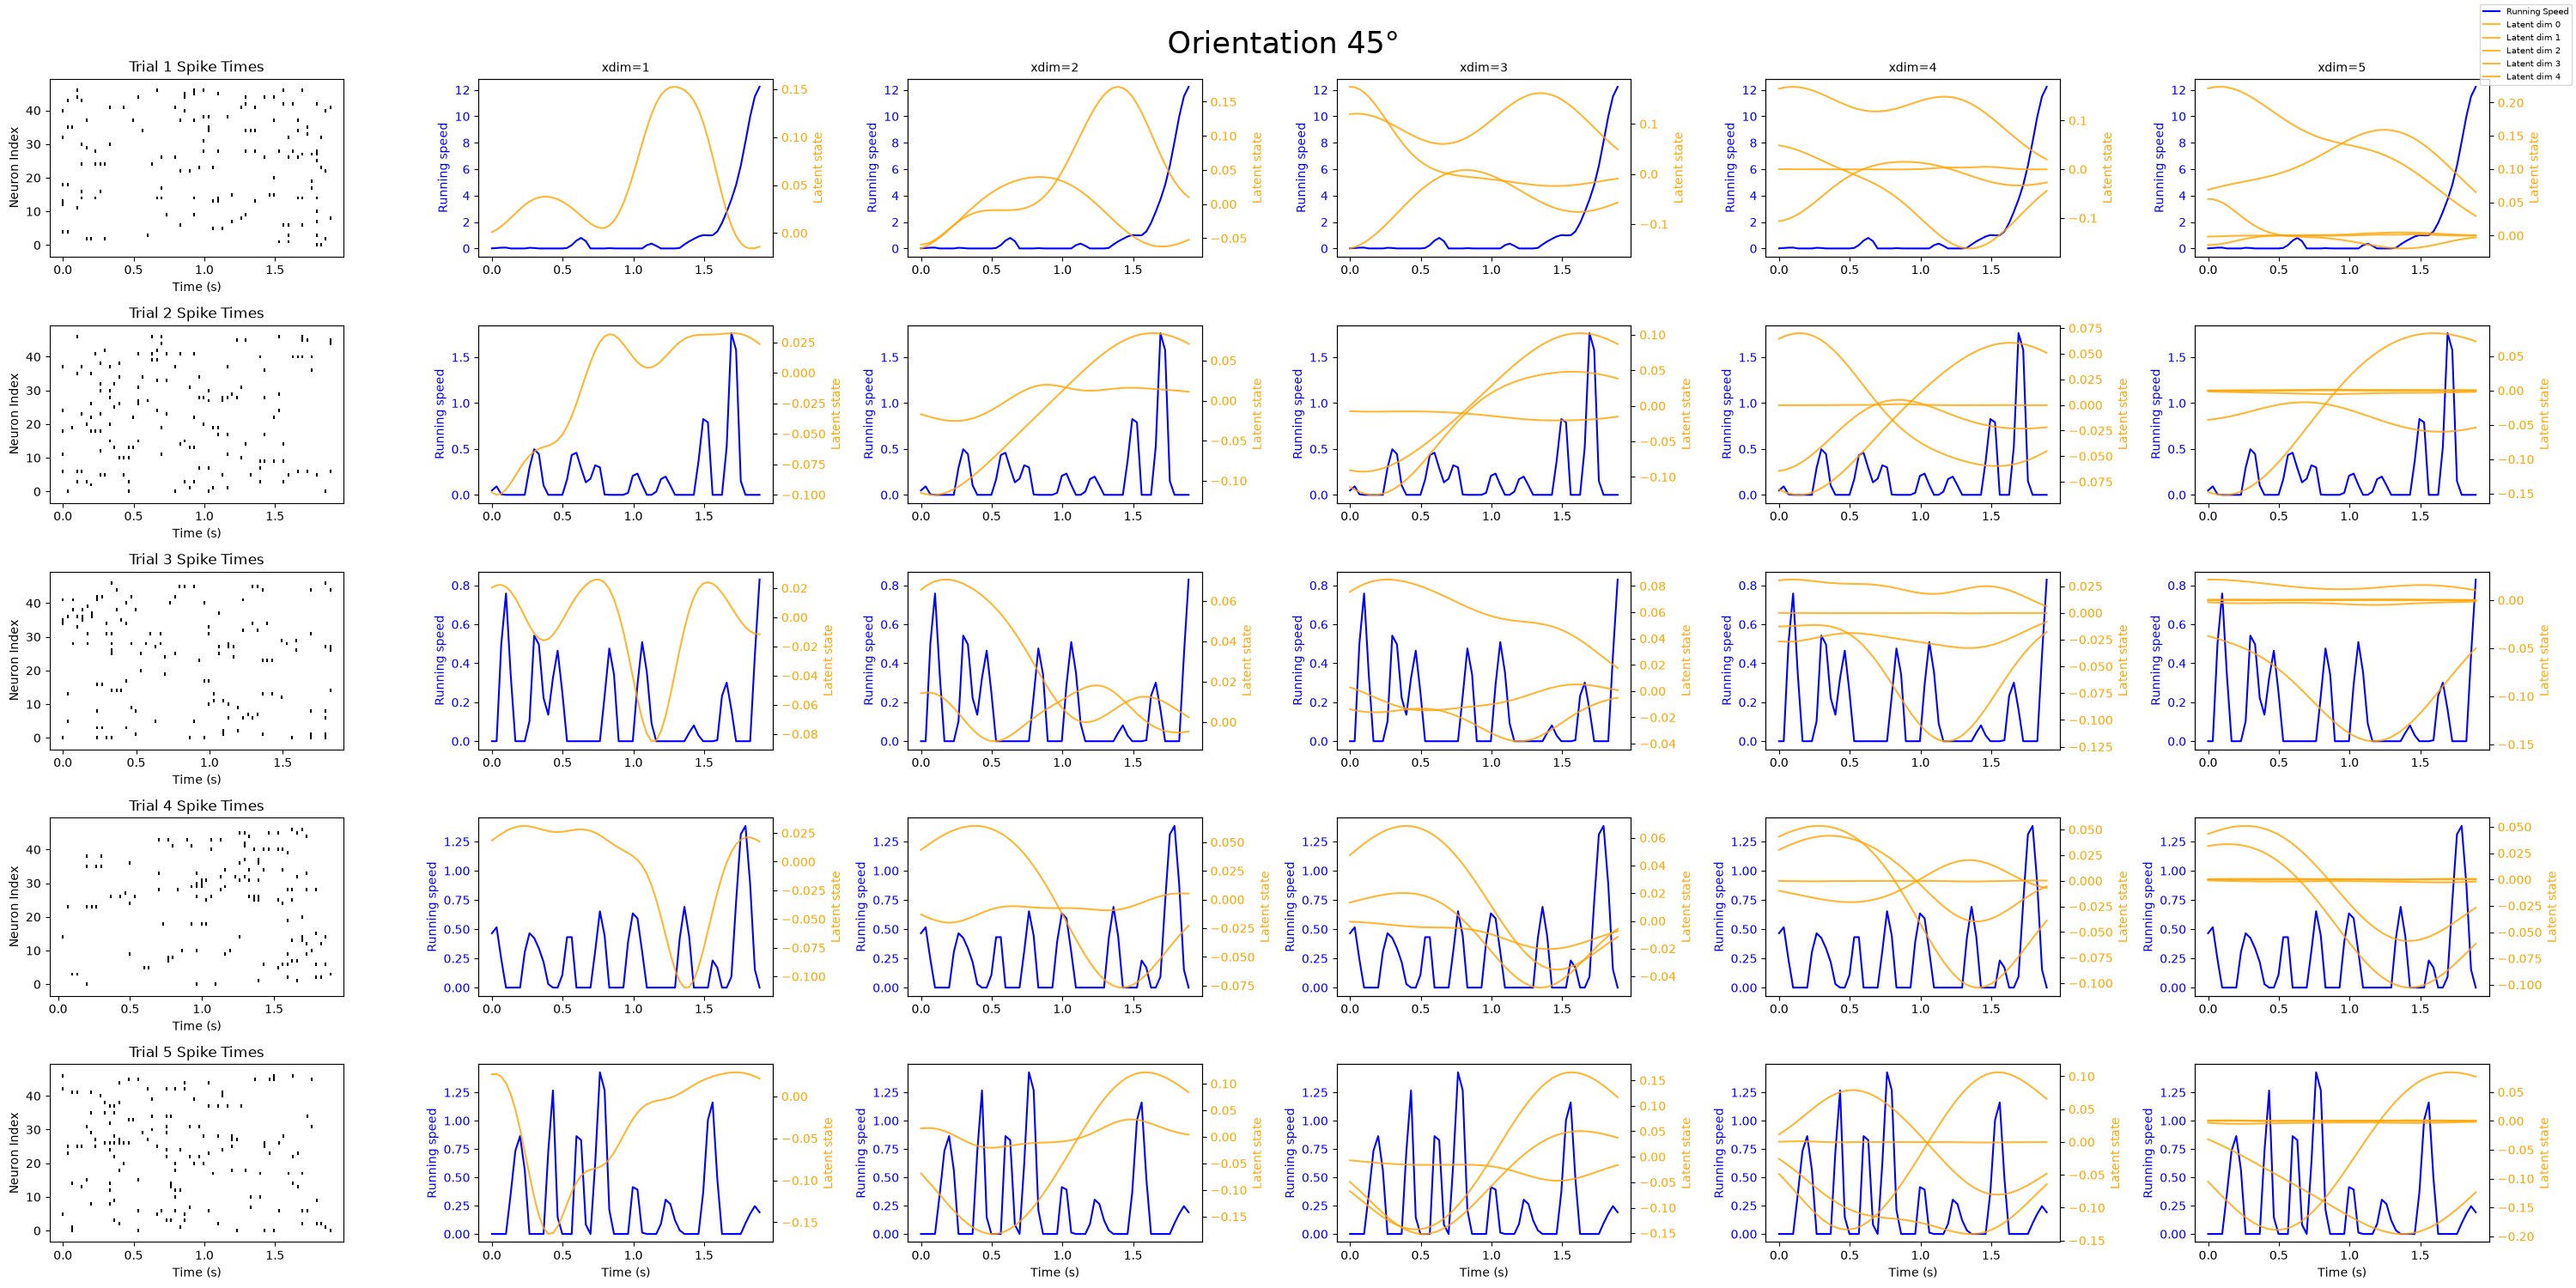

In [31]:
fig, axes = plot_gpfa_latent_and_speed(
    xval=xval_drifting_gratings_45,
    data=data_drifting_gratings_45,
    nr_trials=5
)
plt.show()

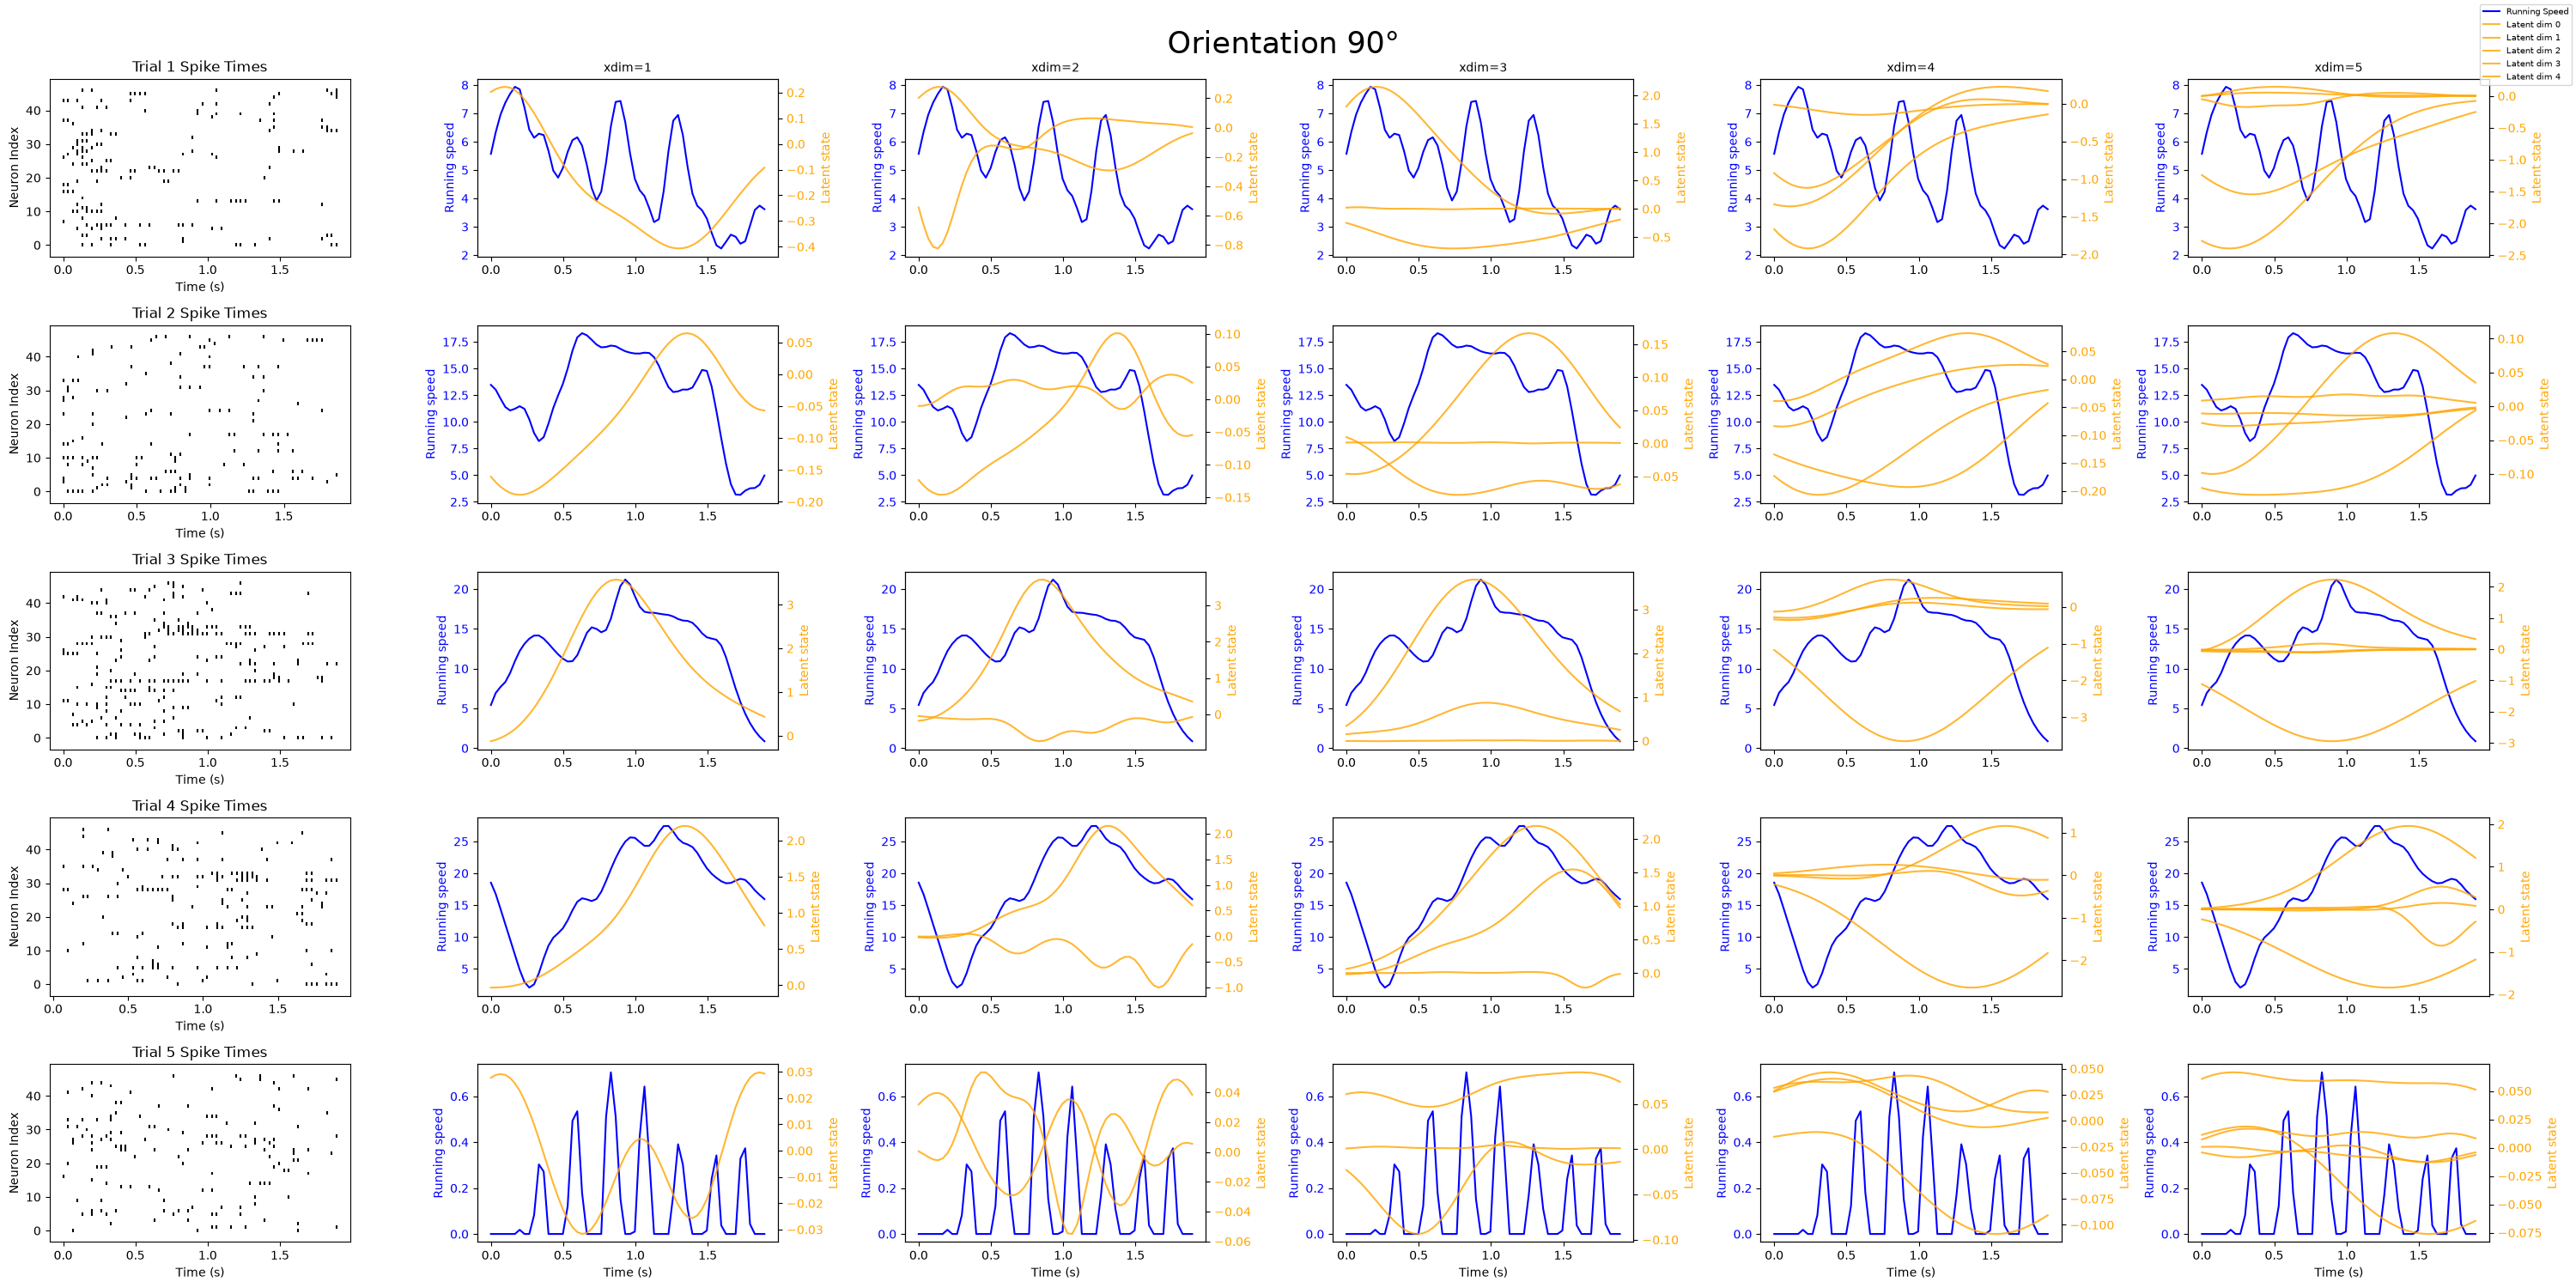

In [32]:
fig, axes = plot_gpfa_latent_and_speed(
    xval=xval_drifting_gratings_90,
    data=data_drifting_gratings_90,
    nr_trials=5
)
plt.show()

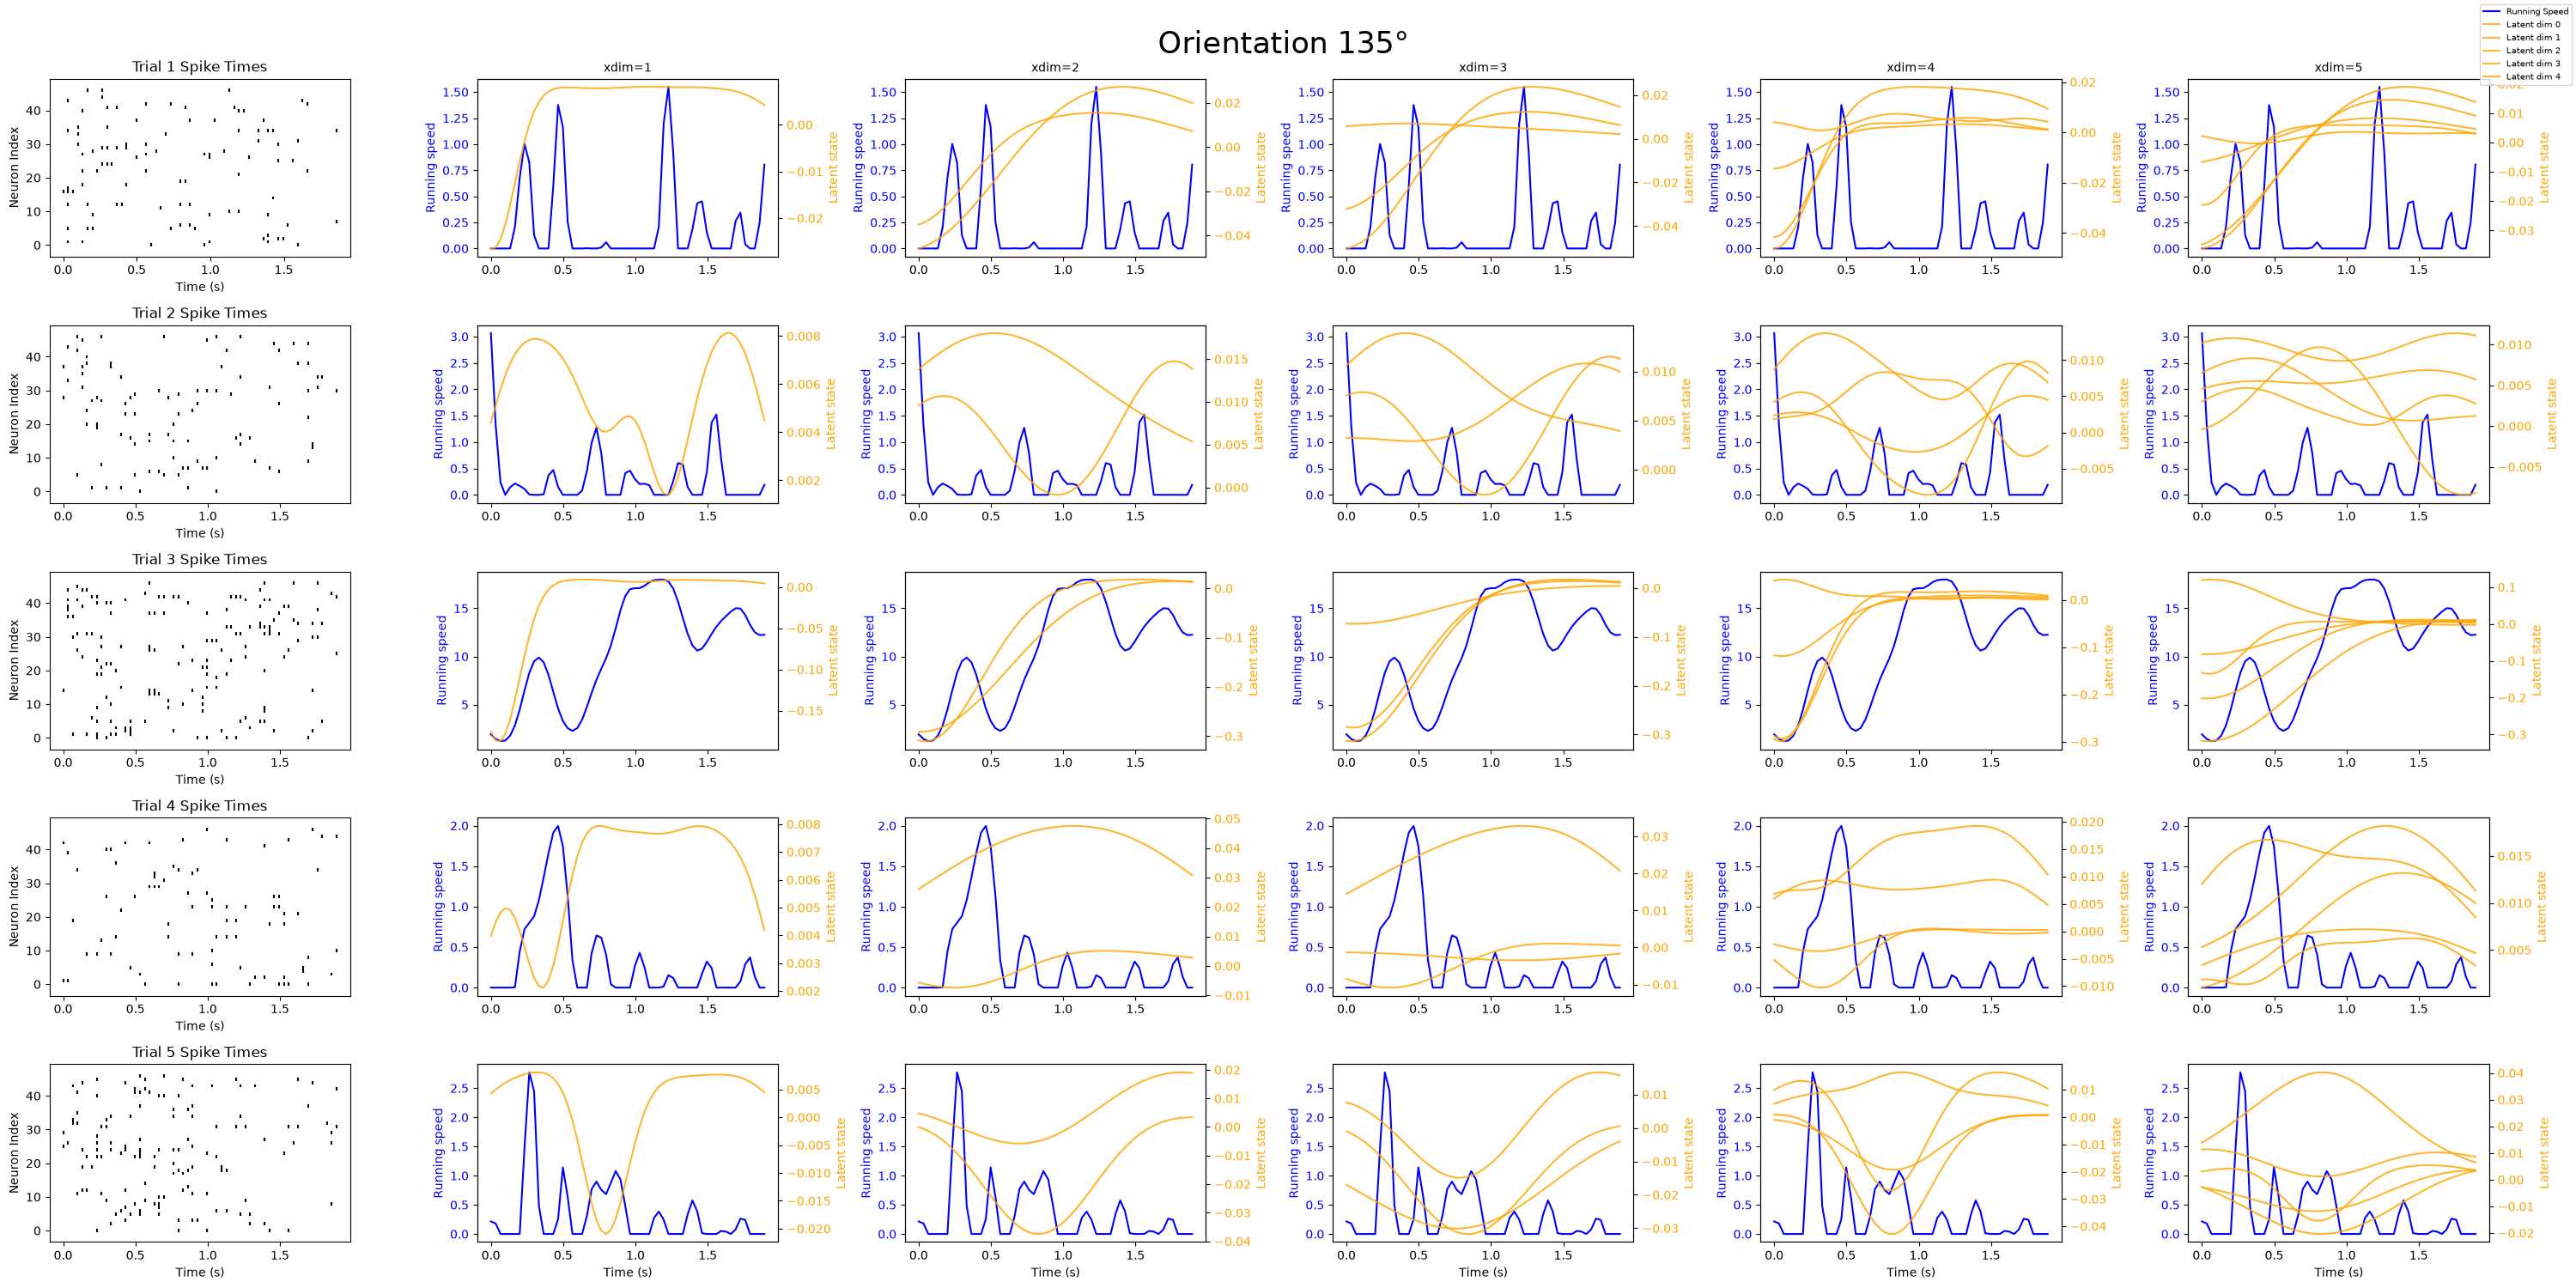

In [33]:
fig, axes = plot_gpfa_latent_and_speed(
    xval=xval_drifting_gratings_135, 
    data=data_drifting_gratings_135,
    nr_trials=5
)
plt.show()

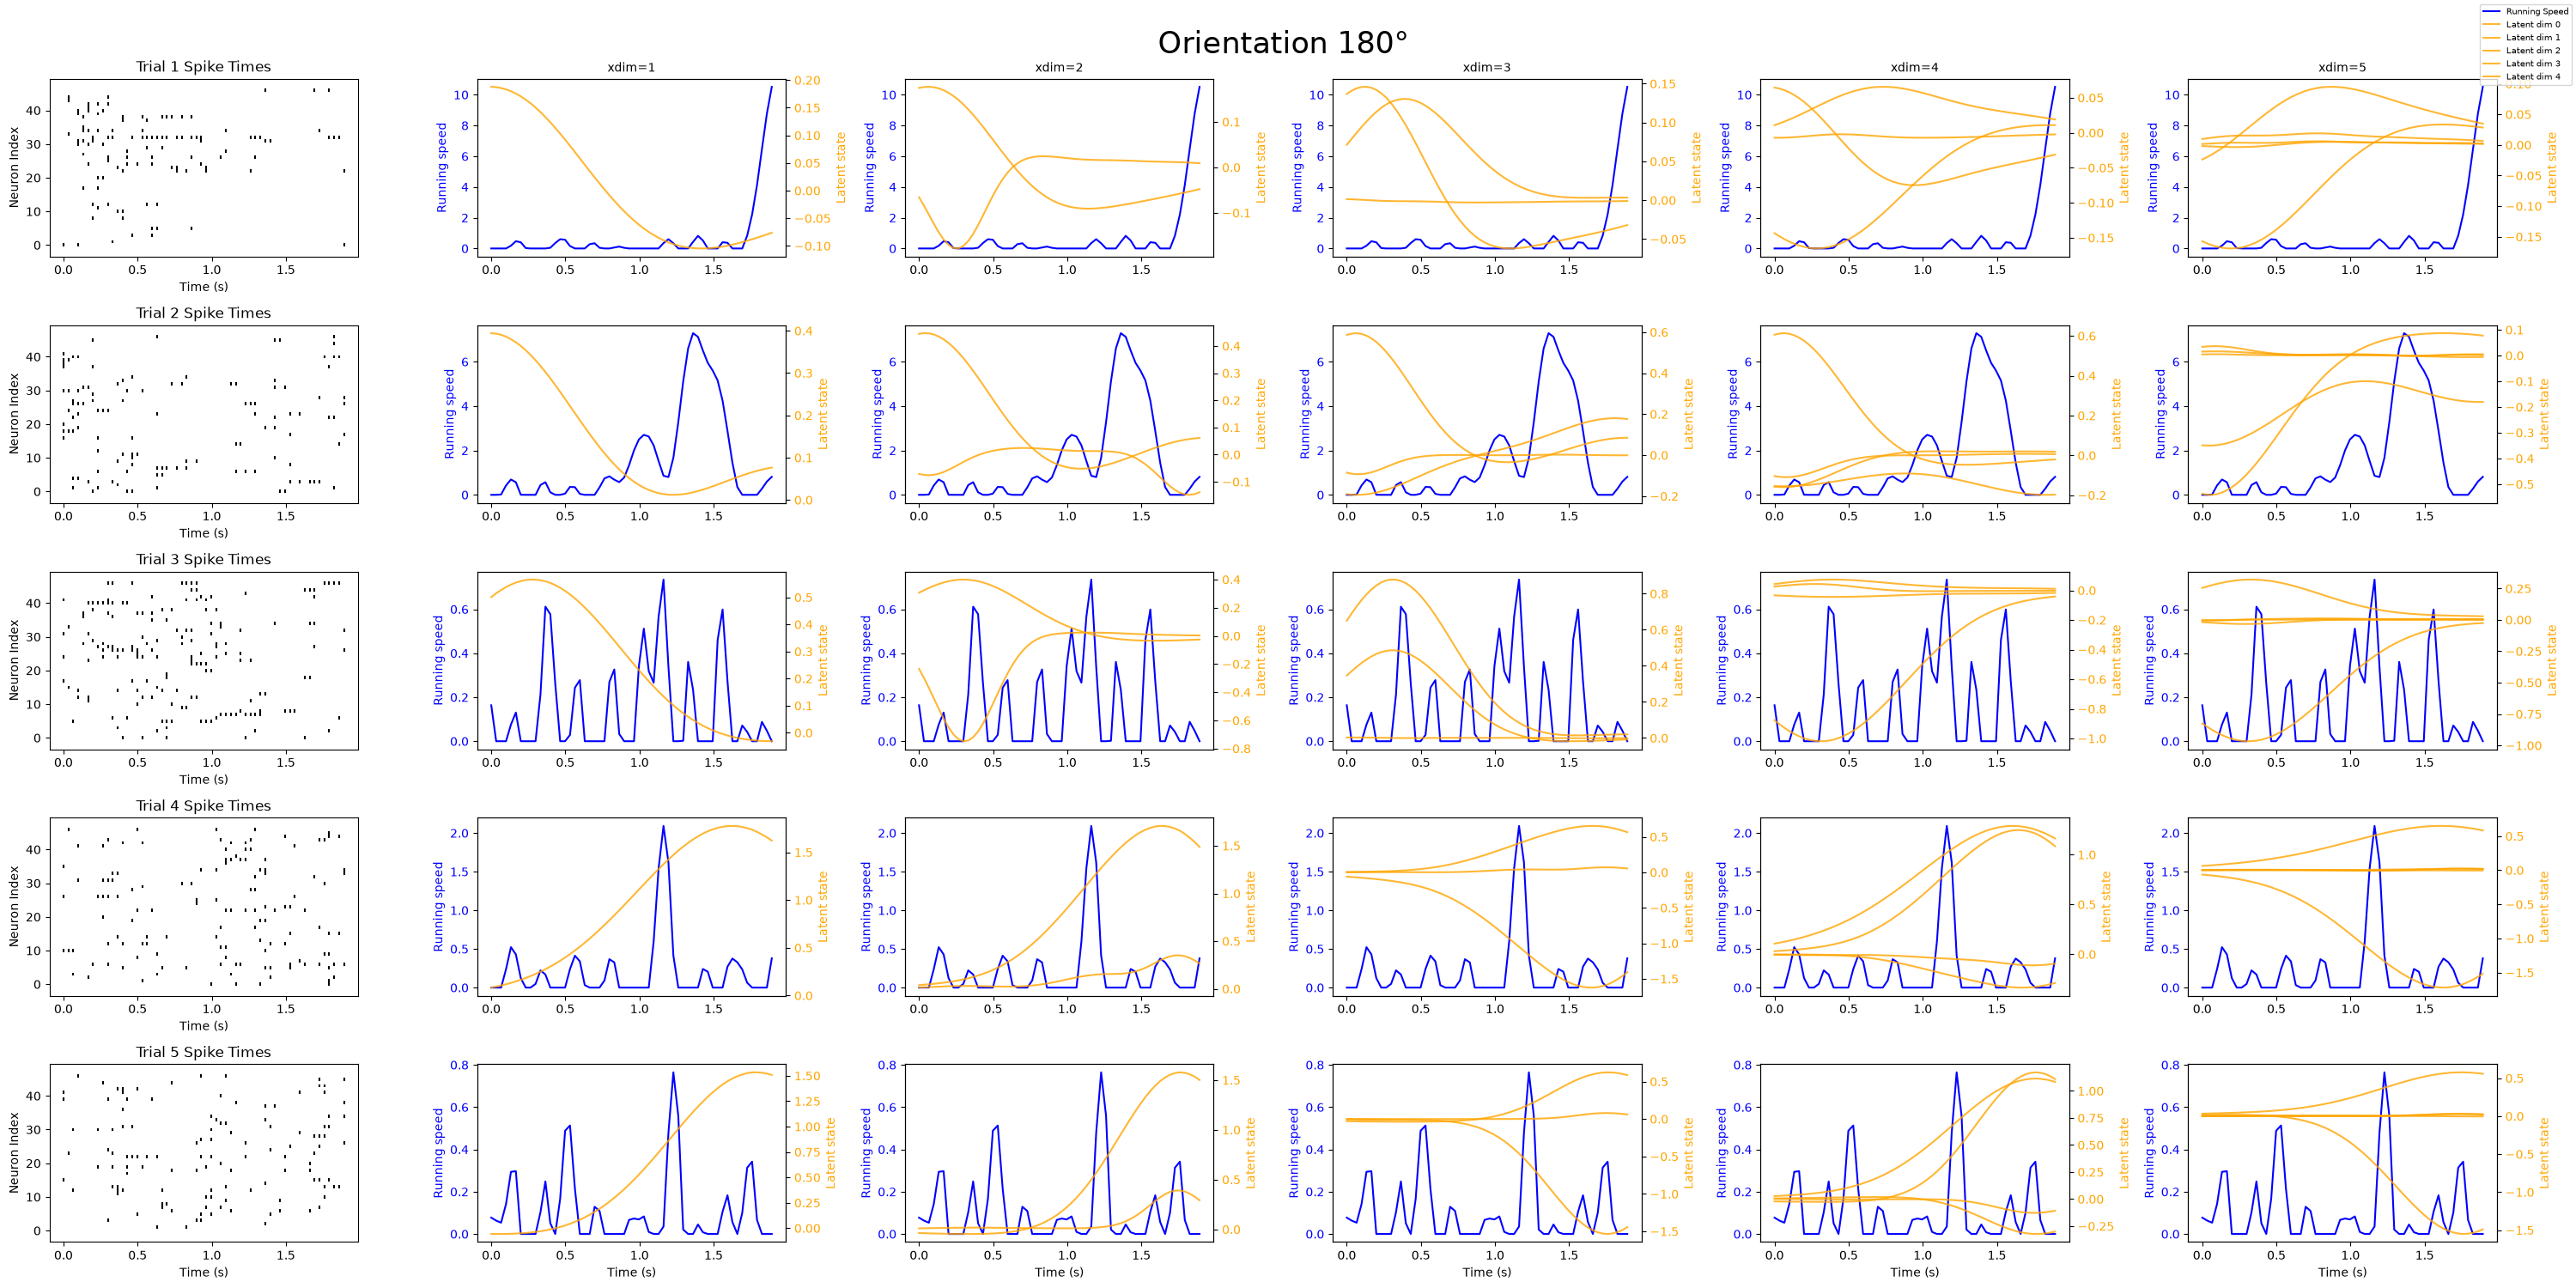

In [34]:
fig, axes = plot_gpfa_latent_and_speed(
    xval=xval_drifting_gratings_180,
    data=data_drifting_gratings_180,
    nr_trials=5
)